Lugo Avalos Vanessa Aidee

# Librerías
Se importan las librerías necesarias para manipulacón de datos, visualización, entrenamiento de modelos, y métricas.

In [ ]:
%pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 43.7 MB/s eta 0:00:00


In [ ]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import confusion_matrix
from sklearn.datasets import fetch_openml
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import classification_report

# Banco de datos
Se carga el conjunto de datos, el cual contiene 70 000 imágenes de dígitos del 0 al 9, donde cada imagen tiene 28x28 píxeles

In [ ]:
mnist = fetch_openml('mnist_784', version = 1)
X = mnist.data
y = mnist.target.astype(int)

# Tamaño del banco de datos y clases
Se realiza la impresión del tamaño del conjunto de datos, el cual corresponde a 70000 registros con imágenes de 28x28 píxeles, es decir, 784 datos. Además, muestran los datos únicos, los cuales corresponden a los dígitos

In [ ]:
print("Tamaño del dataset:", X.shape)
print("Clases únicas:", np.unique(y))

Tamaño del dataset: (70000, 784)
Clases únicas: [0 1 2 3 4 5 6 7 8 9]


# Impresión de imágenes aleatorias
Se define una función para mostrar 10 imágenes de manera aleatoria, de manera que se selecciona una por cada clase, mostrando así la clase y la imagen que corresponde.

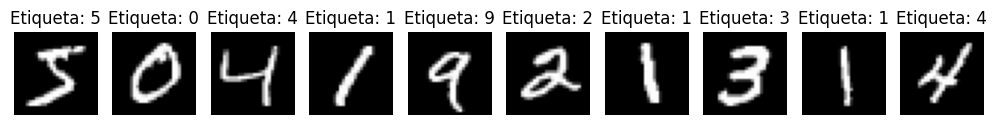

In [ ]:
def plot_digits(images, labels, n = 10):
    plt.figure(figsize = (10, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap = 'gray')
        plt.title(f"Etiqueta: {labels[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_digits(X.to_numpy(), y)

# Reducción con PCA
Debido a la gran cantidad de dimensiones, es decir, 784 dimensiones, se aplica Análisis de Componentes Principales (PCA) para reducir esta cantidad con variables que concentren la mayor información, en este caso, se asignan 2 componenetes a manera de que se puedan visualizar los datos.

In [ ]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)

# Gráfica del conjunto de datos con PCA
Con base en la reducción de dimensionalidad a dos componentes, se raliza la gráfica para visualizar los datos en dos dimensiones, donde se observa que la mayoría de los dígitos son complicados de diferenciar o de separar facilmente, y que solo que 0 y el 1 parecen estar bien definidos.

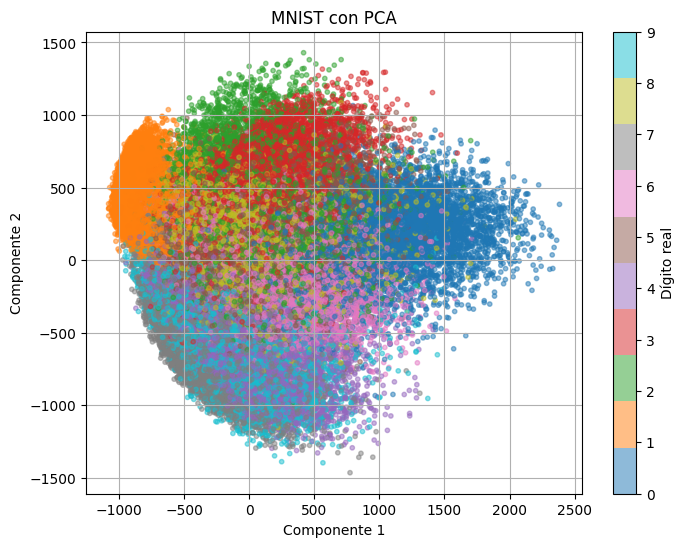

In [ ]:
plt.figure(figsize = (8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = y, cmap = 'tab10', alpha = 0.5, s = 10)
plt.title("MNIST con PCA")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.colorbar(label = "Dígito real")
plt.grid(True)
plt.show()

# k-means
Se aplica el algoritmo de k-means (k-medias) que se trata de un algoritmo de aprendizaje no supervisado de clustering, que se utiliza cuando se tienen datos sin etiquetar. Este algoritmo trabaja de manera iterativa para asignar a cada punto uno de los "K" grupos de acuerdo con sus características, donde se obtienen los centroides que son las coordenadas de cada k, además de las etiquetas para el conjunto de datos.

In [ ]:
kmeans = KMeans(n_clusters = 10, random_state = 7)
labels_kmeans = kmeans.fit_predict(X_pca)

# Resultados K-means
Se muestra de manera gráfica el resultado de haber aplicado el algorimo de k-means para agrupar los datos, se observa que hay 10 centroides, donde cada uno corresponde a cada clase, y los colores son los puntos que pertenecen a esa clase, de manera que se ven separados.

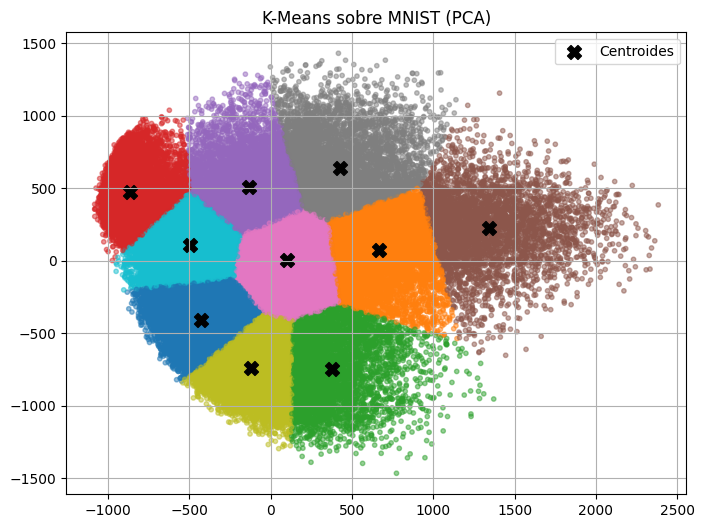

In [ ]:
plt.figure(figsize = (8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = labels_kmeans, cmap = 'tab10', alpha = 0.5, s = 10)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c = 'black', marker = 'X', s = 100, label = 'Centroides')
plt.title("K-Means sobre MNIST (PCA)")
plt.legend()
plt.grid(True)
plt.show()

# C-means difuso (Transponer formato, Asignación, Resultados)
C-means difruso o Fuzzy c-Means (FCM) es un algoritmo de aprendizaje no supervisado por método de agrupación (clustering) que permite que un elemento pertenezca a varios grupos al mismo tiempo, en lugar de asignarlo a una sola clase. Esto es diferente a K-means, pues este solo asigna una clase a cada punto.

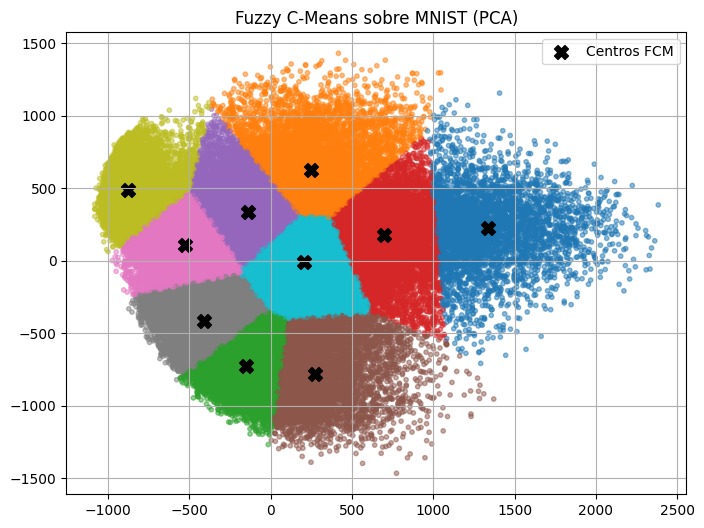

In [ ]:
X_fcm = X_pca.T
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(X_fcm, c = 10, m = 2, error = 0.005, maxiter = 1000)

labels_fcm = np.argmax(u, axis = 0)

plt.figure(figsize = (8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = labels_fcm, cmap = 'tab10', alpha = 0.5, s = 10)
plt.scatter(cntr[:, 0], cntr[:, 1], c = 'black', marker = 'X', s = 100, label = 'Centros FCM')
plt.title("Fuzzy C-Means sobre MNIST (PCA)")
plt.legend()
plt.grid(True)
plt.show()

# Posibilista c-means
C-Medias posibilisticas es un algoritmo de agrupamiento de datos que también permite que un punto pertenezca a diferentes grupos, además, elimina la regla de Fuzzy C-Means donde los grados de pertenencia de un punto a todos los grupos debben sumar 1.

In [ ]:
def possibilistic_c_means(X, cntr_init, m = 2, max_iter = 100, epsilon = 1e-5):
    n_samples = X.shape[0]
    n_clusters = cntr_init.shape[0]
    cntr = cntr_init.copy()
    t = np.zeros((n_clusters, n_samples))

    for _ in range(max_iter):
        cntr_old = cntr.copy()
        for i in range(n_clusters):
            dist = np.linalg.norm(X - cntr[i], axis = 1)**2
            eta = np.mean(dist)
            t[i] = 1 / (1 + (dist / eta)**(1 / (m - 1)))
        for i in range(n_clusters):
            numer = np.sum((t[i]**m)[:, np.newaxis] * X, axis = 0)
            denom = np.sum(t[i]**m)
            cntr[i] = numer / denom
        if np.linalg.norm(cntr - cntr_old) < epsilon:
            break
    return cntr, t

cntr_pcm, t_pcm = possibilistic_c_means(X_pca, cntr)

labels_pcm = np.argmax(t_pcm, axis = 0)

# Resultados posibilista c-means

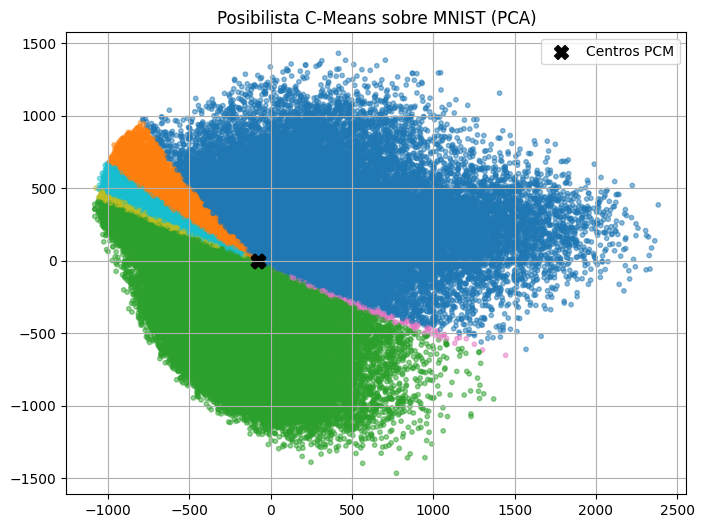

In [ ]:
plt.figure(figsize = (8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = labels_pcm, cmap = 'tab10', alpha = 0.5, s = 10)
plt.scatter(cntr_pcm[:, 0], cntr_pcm[:, 1], c = 'black', marker = 'X', s = 100, label = 'Centros PCM')
plt.title("Posibilista C-Means sobre MNIST (PCA)")
plt.legend()
plt.grid(True)
plt.show()

# Tabla de pertenencia de datos a los clústeres
Se realiza un tabla a mmanera de comparar las etiquetas que asigna cada timpo de algoritmo de aprendizaje no supervisado, donde se muestra el dato real del punto y el predicho por cada uno.

In [ ]:
df_resultados = pd.DataFrame({
    "Punto": range(10),
    "Etiqueta real": y[:10],
    "KMeans": labels_kmeans[:10],
    "Fuzzy C-Means": labels_fcm[:10],
    "Possibilistic C-Means": labels_pcm[:10]
})

print("\n\tTabla de pertenencia de clústeres (primeros 10 puntos)\n")
print(df_resultados)


	Tabla de pertenencia de clústeres (primeros 10 puntos)

   Punto  Etiqueta real  KMeans  Fuzzy C-Means  Possibilistic C-Means
0      0              5       6              4                      0
1      1              0       5              3                      0
2      2              4       8              2                      2
3      3              1       3              8                      1
4      4              9       8              2                      2
5      5              2       6              9                      2
6      6              1       9              6                      2
7      7              3       1              3                      0
8      8              1       9              6                      2
9      9              4       0              7                      2


# Calcular e imprimir el uso de cada clúster en Possibilistic C-Means

In [ ]:
uso = [(i, np.max(t_pcm[i]), np.mean(t_pcm[i])) for i in range(t_pcm.shape[0])]

print("\n Intensidad de uso de cada clúster (PCM):")
for i, max_val, avg_val in uso:
    print(f"Clúster {i}: máximo = {max_val:.4f}, promedio = {avg_val:.4f}")


 Intensidad de uso de cada clúster (PCM):
Clúster 0: máximo = 1.0000, promedio = 0.5873
Clúster 1: máximo = 1.0000, promedio = 0.5873
Clúster 2: máximo = 1.0000, promedio = 0.5873
Clúster 3: máximo = 1.0000, promedio = 0.5873
Clúster 4: máximo = 1.0000, promedio = 0.5873
Clúster 5: máximo = 1.0000, promedio = 0.5873
Clúster 6: máximo = 1.0000, promedio = 0.5873
Clúster 7: máximo = 1.0000, promedio = 0.5873
Clúster 8: máximo = 1.0000, promedio = 0.5873
Clúster 9: máximo = 1.0000, promedio = 0.5873


# Etiquetas del banco de datos y Cálculo de Métricas (ARI y NMI)
Se evalua que tan buenos fueron los cluteres obtenidos por cada algoritmo, de manera que se compara contra las etiquetas reales del conjunto de datos. Se realiza el calculo de Adjusted Rand Index para comparar la etiqueta real del cluster generado, también se calcula Normalized Mutual Information, el cual mide cuanta información comparte las etiquetas reales y los clusters encontrados. Se observa que, los tres algoritmos tuvieron un rendimiento bastante similar, pero se destaca k-means por tener mejores resultados.

In [ ]:
y_true = mnist.target.astype(int)[:len(labels_kmeans)]

print("K-Means ARI:", adjusted_rand_score(y_true, labels_kmeans))
print("FCM ARI:", adjusted_rand_score(y_true, labels_fcm))
print("PCM ARI:", adjusted_rand_score(y_true, labels_pcm))

print("K-Means NMI:", normalized_mutual_info_score(y_true, labels_kmeans))
print("FCM NMI:", normalized_mutual_info_score(y_true, labels_fcm))
print("PCM NMI:", normalized_mutual_info_score(y_true, labels_pcm))

K-Means ARI: 0.23290294866321243
FCM ARI: 0.22840727960467372
PCM ARI: 0.13532638630141958
K-Means NMI: 0.3563372437340585
FCM NMI: 0.3532968261817098
PCM NMI: 0.27264708716300196


# Función para mapear etiquetas de clúster a etiquetas reales
Se realiza una funcón que convierte los números de los clusters en las etiquetas reaes de los dígitos, esto para poder calcuar las métricas.

In [ ]:
def map_cluster_labels_verbose(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    print("Mapeo clúster a etiqueta:", mapping)
    new_labels = np.array([mapping[label] for label in y_pred])
    return new_labels

# Aplicar mapeo a cada algoritmo.
Se aplica la función anterior de mapeo a cada algoritmo.

In [ ]:
labels_kmeans_mapped = map_cluster_labels_verbose(y_true, labels_kmeans)
labels_fcm_mapped = map_cluster_labels_verbose(y_true, labels_fcm)
labels_pcm_mapped = map_cluster_labels_verbose(y_true, labels_pcm)

Mapeo clúster a etiqueta: {np.int64(5): np.int64(0), np.int64(3): np.int64(1), np.int64(4): np.int64(2), np.int64(7): np.int64(3), np.int64(2): np.int64(4), np.int64(9): np.int64(5), np.int64(1): np.int64(6), np.int64(0): np.int64(7), np.int64(6): np.int64(8), np.int64(8): np.int64(9)}
Mapeo clúster a etiqueta: {np.int64(0): np.int64(0), np.int64(8): np.int64(1), np.int64(3): np.int64(2), np.int64(1): np.int64(3), np.int64(5): np.int64(4), np.int64(6): np.int64(5), np.int64(9): np.int64(6), np.int64(2): np.int64(7), np.int64(4): np.int64(8), np.int64(7): np.int64(9)}
Mapeo clúster a etiqueta: {np.int64(0): np.int64(0), np.int64(8): np.int64(1), np.int64(6): np.int64(2), np.int64(4): np.int64(3), np.int64(3): np.int64(4), np.int64(7): np.int64(5), np.int64(5): np.int64(6), np.int64(2): np.int64(7), np.int64(1): np.int64(8), np.int64(9): np.int64(9)}


# Función para mostrar la matriz de confusión
Se realiza una funcion para mostrar cada matriz de confusión correspondiente a cada algorimo con la finalidad de compararlos.

In [ ]:
def graficar_matriz_confusion(y_true, y_pred, title, cmap):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize = (8, 7))
    sns.heatmap(cm, cmap = cmap, cbar = True, square = True,
                xticklabels = [str(i) for i in range(10)],
                yticklabels = [str(i) for i in range(10)],
                linewidths = 0.5, linecolor = 'gray',
                annot = False, ax = ax)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            ax.text(j + 0.5, i + 0.5, f'{value:,}',
                    ha = 'center', va = 'center',
                    color = 'black', fontsize = 12)

    ax.set_xlabel("Etiqueta asignada", fontsize = 12)
    ax.set_ylabel("Etiqueta real", fontsize = 12)
    ax.set_title(title, fontsize = 14)
    plt.tight_layout()
    plt.show()

# Matrices de confusión
Se aplica la función para realizar la geáfica da cada modelo, donde se observa que el modelo con mejor rendimiento fue k-means

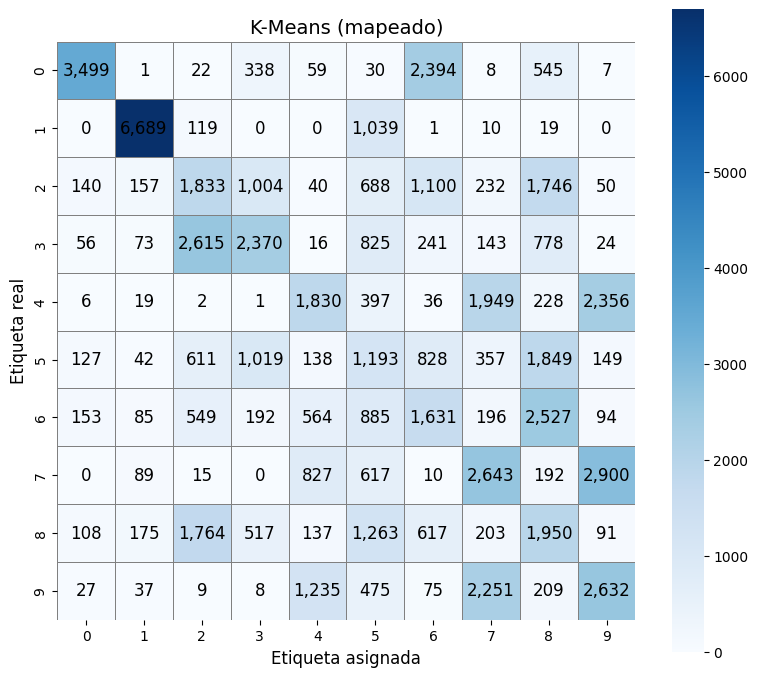

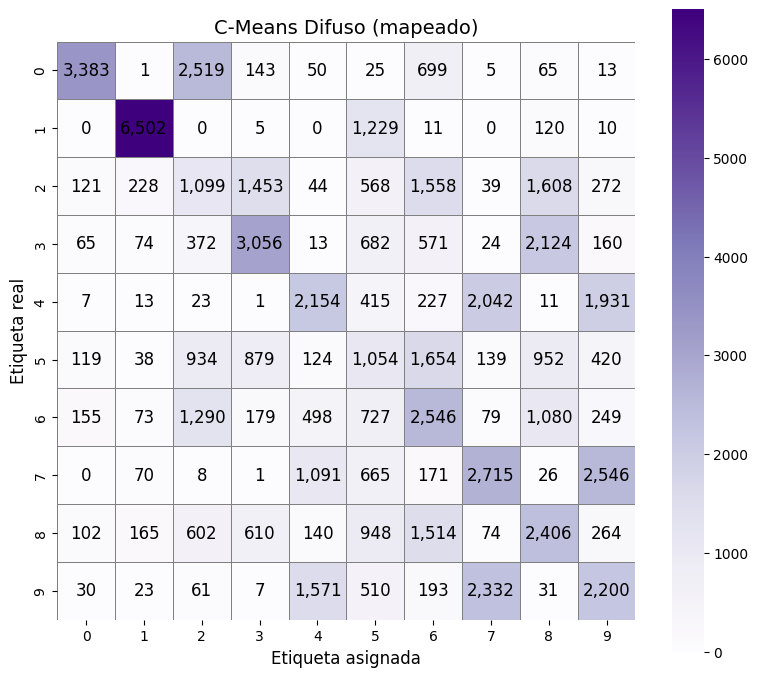

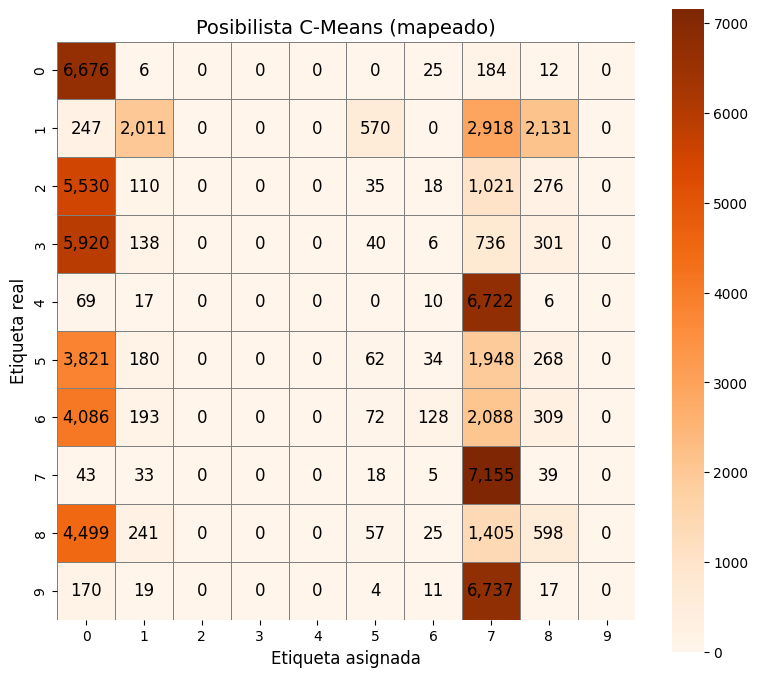

In [ ]:
graficar_matriz_confusion(y_true, labels_kmeans_mapped, "K-Means (mapeado)", "Blues")

graficar_matriz_confusion(y_true, labels_fcm_mapped, "C-Means Difuso (mapeado)", "Purples")

graficar_matriz_confusion(y_true, labels_pcm_mapped, "Posibilista C-Means (mapeado)", "Oranges")

# Reportes de clasificación
Se realiza el reporte de clasificación para cada algoritmo, se tiene que k-means y Fuccy C-means tienen un rendimiento parecido, sin embargo, PCM es el modelo con peor rendimieno

In [ ]:
print("\n\tReporte de clasificación: K-Means (mapeado)\n")
print(classification_report(y_true, labels_kmeans_mapped, digits = 3))

print("\n\tReporte de clasificación: C-Means Difuso (mapeado)\n")
print(classification_report(y_true, labels_fcm_mapped, digits = 3))

print("\n\tReporte de clasificación: C-Means Posibilístico (mapeado)\n")
print(classification_report(y_true, labels_pcm_mapped, digits=4))


	Reporte de clasificación: K-Means (mapeado)

              precision    recall  f1-score   support

           0      0.850     0.507     0.635      6903
           1      0.908     0.849     0.878      7877
           2      0.243     0.262     0.252      6990
           3      0.435     0.332     0.376      7141
           4      0.378     0.268     0.314      6824
           5      0.161     0.189     0.174      6313
           6      0.235     0.237     0.236      6876
           7      0.331     0.362     0.346      7293
           8      0.194     0.286     0.231      6825
           9      0.317     0.378     0.345      6958

    accuracy                          0.375     70000
   macro avg      0.405     0.367     0.379     70000
weighted avg      0.414     0.375     0.387     70000


	Reporte de clasificación: C-Means Difuso (mapeado)

              precision    recall  f1-score   support

           0      0.850     0.490     0.622      6903
           1      0.905     0.8

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Conclusiones
En consusión el aprendizaje no supervisasdo es un método relevante ya que permite realizar la separaci;on de datos sin necesidad de conocer las etiquetas reales, lo cual es útil en la práctica con datos que no tienen esta identificacion